# Multi-Disease Prediction System

## Project Overview

This project develops a machine learning based Multi-Disease Prediction System
for predicting:

1. Chronic Kidney Disease (CKD)
2. Heart Disease

Two separate classification models are developed because the two diseases use
different datasets and different medical features.

The complete workflow includes:

- Dataset loading
- Data cleaning
- Exploratory Data Analysis
- Train-test splitting
- Data preprocessing
- Machine learning model training
- Model comparison
- Performance evaluation
- Confusion matrix
- Feature importance
- Saving the best models for dashboard deployment

### Objective

The main objective is to build a simple machine learning system that can
predict whether a patient is likely to have CKD or Heart Disease based on
structured medical attributes.

## Datasets Used

### 1. Chronic Kidney Disease Dataset

The CKD dataset contains medical and laboratory features such as:

- Age
- Blood Pressure
- Specific Gravity
- Albumin
- Blood Glucose
- Blood Urea
- Serum Creatinine
- Hemoglobin
- Packed Cell Volume
- Hypertension
- Diabetes Mellitus
- Appetite
- Anemia

The target variable is:

- `ckd` → Chronic Kidney Disease
- `notckd` → No Chronic Kidney Disease


### 2. Heart Disease Dataset

The Heart Disease dataset contains features such as:

- Age
- Sex
- Chest Pain Type
- Resting Blood Pressure
- Cholesterol
- Maximum Heart Rate
- Exercise-Induced Angina
- ST Depression
- Slope
- Number of Major Vessels
- Thalassemia

The original target contains multiple classes. For this project it is converted
into a binary classification problem:

- `0` → No Heart Disease
- `1` → Heart Disease

In [ ]:
## Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

# Step 2: Upload the Datasets

Upload the following two files:

1. `chronic_kidney_disease.arff`
2. `processed.cleveland.data`

In [ ]:
print("Upload chronic_kidney_disease.arff")
kidney_upload = files.upload()

print("\nUpload processed.cleveland.data")
heart_upload = files.upload()

print("\nDatasets uploaded successfully.")

Upload chronic_kidney_disease.arff


Saving chronic_kidney_disease.arff to chronic_kidney_disease (1).arff

Upload processed.cleveland.data


Saving processed.cleveland.data to processed.cleveland (1).data

Datasets uploaded successfully.


# Step 3: Load and Clean the CKD Dataset

The CKD dataset is provided in ARFF format.

The dataset is read manually so that the data section can be extracted
correctly and irregular rows can be handled before creating the DataFrame.

In [ ]:
kidney_file = "chronic_kidney_disease.arff"

with open(kidney_file, "r", encoding="utf-8") as file:
    lines = file.readlines()

# Find the @data section
data_start = None

for i, line in enumerate(lines):
    if line.strip().lower() == "@data":
        data_start = i + 1
        break

if data_start is None:
    raise ValueError("@data section not found in the CKD file.")

# Extract actual data rows
rows = []

for line in lines[data_start:]:
    line = line.strip()

    if line and not line.startswith("%"):
        rows.append([value.strip() for value in line.split(",")])

print("Number of raw rows:", len(rows))

Number of raw rows: 400


In [ ]:
ckd_columns = [
    "age", "bp", "sg", "al", "su",
    "rbc", "pc", "pcc", "ba",
    "bgr", "bu", "sc", "sod", "pot",
    "hemo", "pcv", "wbcc", "rbcc",
    "htn", "dm", "cad", "appet", "pe", "ane",
    "class"
]

fixed_rows = []

for row in rows:

    # Remove an extra empty field
    if len(row) == 26 and row[-1] == "":
        row = row[:-1]

    # Repair the known malformed row pattern
    elif len(row) == 26 and row[21] == "no" and row[22] == "good":
        row.pop(21)

    if len(row) == 25:
        fixed_rows.append(row)

kidney_df = pd.DataFrame(
    fixed_rows,
    columns=ckd_columns
)

print("CKD Dataset Shape:", kidney_df.shape)
kidney_df.head()

CKD Dataset Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,?,normal,notpresent,notpresent,121,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,?,normal,notpresent,notpresent,?,...,38,6000,?,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,31,7500,?,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,35,7300,4.6,no,no,no,good,no,no,ckd


## CKD Data Cleaning

The dataset contains missing values represented by `?`.

Instead of manually filling these values before splitting the dataset, missing
values will be handled later using a Scikit-learn preprocessing pipeline.

This is important because preprocessing should be learned only from the
training data to avoid data leakage.

In [ ]:
# Replace ? with NaN
kidney_df = kidney_df.replace("?", np.nan)

# Remove extra spaces and convert target to lowercase
kidney_df["class"] = (
    kidney_df["class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert CKD target into binary values
kidney_df["class"] = kidney_df["class"].map({
    "notckd": 0,
    "ckd": 1
})

print("Missing values:", kidney_df.isnull().sum().sum())
print("\nTarget distribution:")
print(kidney_df["class"].value_counts())

kidney_df.head()

Missing values: 1012

Target distribution:
class
1    250
0    150
Name: count, dtype: int64


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,NaN,normal,notpresent,notpresent,121,...,44,7800,5.2,yes,yes,no,good,no,no,1
1,7,50,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,1
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,31,7500,NaN,no,yes,no,poor,no,yes,1
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,35,7300,4.6,no,no,no,good,no,no,1


## CKD Dataset Information

The CKD dataset contains both numerical and categorical features.

Numerical features contain measurable medical values, while categorical
features contain values such as yes/no or normal/abnormal.

In [ ]:
ckd_numeric_cols = [
    "age", "bp", "sg", "al", "su",
    "bgr", "bu", "sc", "sod", "pot",
    "hemo", "pcv", "wbcc", "rbcc"
]

ckd_categorical_cols = [
    "rbc", "pc", "pcc", "ba",
    "htn", "dm", "cad", "appet", "pe", "ane"
]

# Convert numerical columns to numeric
for col in ckd_numeric_cols:
    kidney_df[col] = pd.to_numeric(
        kidney_df[col],
        errors="coerce"
    )

print("Numerical columns:", len(ckd_numeric_cols))
print("Categorical columns:", len(ckd_categorical_cols))

Numerical columns: 14
Categorical columns: 10


## CKD Exploratory Data Analysis

Before training the model, we examine:

- Dataset size
- Missing values
- Target distribution
- Basic statistics

In [ ]:
print("CKD Dataset Shape:", kidney_df.shape)

print("\nMissing Values:")
print(kidney_df.isnull().sum())

print("\nStatistical Summary:")
display(kidney_df[ckd_numeric_cols].describe())

CKD Dataset Shape: (400, 25)

Missing Values:
age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

Statistical Summary:


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


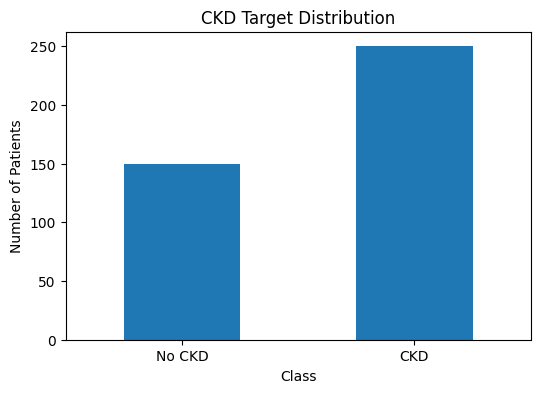

In [ ]:
plt.figure(figsize=(6, 4))

kidney_df["class"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["No CKD", "CKD"],
    rotation=0
)

plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("CKD Target Distribution")

plt.show()

# Step 4: Prepare CKD Data

The target variable is separated from the input features.

The dataset is then divided into training and testing sets.

The test set is kept separate and is not used while learning the preprocessing
steps or training the models.

In [ ]:
X_ckd = kidney_df.drop("class", axis=1)
y_ckd = kidney_df["class"]

X_ckd_train, X_ckd_test, y_ckd_train, y_ckd_test = train_test_split(
    X_ckd,
    y_ckd,
    test_size=0.20,
    random_state=42,
    stratify=y_ckd
)

print("Training samples:", X_ckd_train.shape[0])
print("Testing samples:", X_ckd_test.shape[0])

Training samples: 320
Testing samples: 80


## CKD Preprocessing Pipeline

The preprocessing pipeline performs:

### Numerical features
Missing values are replaced using the median.

### Categorical features
Missing values are replaced using the most frequent value and then converted
into numerical form using One-Hot Encoding.

The preprocessing is fitted only on the training data.

In [ ]:
ckd_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ckd_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ckd_preprocessor = ColumnTransformer([
    ("numeric", ckd_numeric_pipeline, ckd_numeric_cols),
    ("categorical", ckd_categorical_pipeline, ckd_categorical_cols)
])

# Step 5: Train CKD Classification Models

Three classification algorithms are tested:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score

The model with the best F1 score will be selected as the final model.

In [ ]:
ckd_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}


In [ ]:
ckd_results = []
ckd_pipelines = {}

for model_name, model in ckd_models.items():

    pipeline = Pipeline([
        ("preprocessor", ckd_preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_ckd_train,
        y_ckd_train
    )

    y_pred = pipeline.predict(X_ckd_test)

    accuracy = accuracy_score(y_ckd_test, y_pred)
    precision = precision_score(
        y_ckd_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_ckd_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_ckd_test,
        y_pred,
        zero_division=0
    )

    ckd_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    ckd_pipelines[model_name] = pipeline

ckd_results_df = pd.DataFrame(ckd_results)

ckd_results_df = ckd_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(ckd_results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0000,1.000000,1.00,1.000000
1,Logistic Regression,0.9875,1.000000,0.98,0.989899
2,Decision Tree,0.9625,0.979592,0.96,0.969697


## Select the Best Heart Disease Model

In [ ]:
best_ckd_name = ckd_results_df.iloc[0]["Model"]
best_ckd_model = ckd_pipelines[best_ckd_name]

best_ckd_predictions = best_ckd_model.predict(X_ckd_test)

print("Best CKD Model:", best_ckd_name)

Best CKD Model: Random Forest


In [ ]:
print("CKD Classification Report:\n")

print(classification_report(
    y_ckd_test,
    best_ckd_predictions,
    target_names=["No CKD", "CKD"],
    zero_division=0
))

CKD Classification Report:

              precision    recall  f1-score   support

      No CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## CKD Confusion Matrix

A confusion matrix shows:

- True Negative
- False Positive
- False Negative
- True Positive

It helps us understand how well the model distinguishes between CKD and
non-CKD patients.

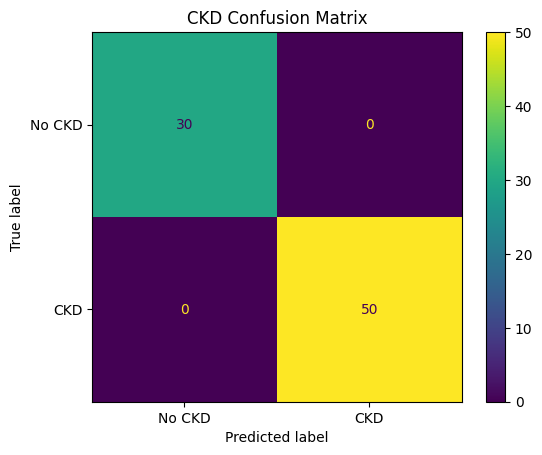

In [ ]:
cm_ckd = confusion_matrix(
    y_ckd_test,
    best_ckd_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ckd,
    display_labels=["No CKD", "CKD"]
)

disp.plot()

plt.title("CKD Confusion Matrix")
plt.show()

# Step 6: Load and Prepare the Heart Disease Dataset

In [ ]:
heart_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

heart_df = pd.read_csv(
    "processed.cleveland.data",
    header=None,
    names=heart_columns,
    na_values="?"
)

print("Heart Dataset Shape:", heart_df.shape)

heart_df.head()

Heart Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Heart Disease Data Cleaning

The Heart Disease dataset contains missing values represented by `?`.

The missing values will be handled using the preprocessing pipeline after the
train-test split.

In [ ]:
heart_numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

heart_categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Convert numerical columns
for col in heart_numeric_cols:
    heart_df[col] = pd.to_numeric(
        heart_df[col],
        errors="coerce"
    )

# Convert categorical columns to numeric where appropriate
for col in heart_categorical_cols:
    heart_df[col] = pd.to_numeric(
        heart_df[col],
        errors="coerce"
    )

# Convert target to numeric
heart_df["target"] = pd.to_numeric(
    heart_df["target"],
    errors="coerce"
)

print("Missing values:")
print(heart_df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## Convert Heart Disease Target to Binary

The original Cleveland dataset contains target values from 0 to 4.

For this project, the target is converted into two classes:

- 0 → No Heart Disease
- 1 → Heart Disease

Any target value greater than 0 is treated as Heart Disease.

In [ ]:
heart_df["target_binary"] = (
    heart_df["target"]
    .apply(lambda x: 0 if x == 0 else 1)
)

print("Heart Disease Target Distribution:")
print(heart_df["target_binary"].value_counts())

Heart Disease Target Distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


## Heart Disease Exploratory Data Analysis

In [ ]:
print("Heart Dataset Shape:", heart_df.shape)

print("\nMissing Values:")
print(heart_df.isnull().sum())

print("\nStatistical Summary:")
display(heart_df[heart_numeric_cols].describe())

Heart Dataset Shape: (303, 15)

Missing Values:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               4
thal             2
target           0
target_binary    0
dtype: int64

Statistical Summary:


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


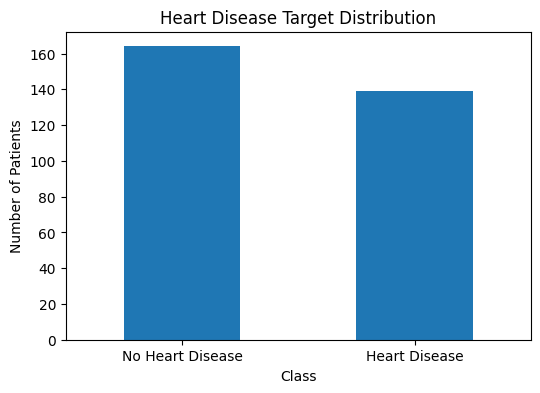

In [ ]:
plt.figure(figsize=(6, 4))

heart_df["target_binary"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["No Heart Disease", "Heart Disease"],
    rotation=0
)

plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Target Distribution")

plt.show()

# Step 7: Prepare Heart Disease Data

The original `target` column and the newly created `target_binary` column
must not be included in the input features.

This prevents target leakage.

In [ ]:
X_heart = heart_df.drop(
    ["target", "target_binary"],
    axis=1
)

y_heart = heart_df["target_binary"]

X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(
    X_heart,
    y_heart,
    test_size=0.20,
    random_state=42,
    stratify=y_heart
)

print("Training samples:", X_heart_train.shape[0])
print("Testing samples:", X_heart_test.shape[0])
print("Number of features:", X_heart_train.shape[1])

Training samples: 242
Testing samples: 61
Number of features: 13


## Heart Disease Preprocessing Pipeline

Numerical features are:

- Missing-value imputation
- Standard scaling

Categorical features are:

- Missing-value imputation
- One-hot encoding

All preprocessing is learned only from the training data.

In [ ]:
heart_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

heart_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

heart_preprocessor = ColumnTransformer([
    ("numeric", heart_numeric_pipeline, heart_numeric_cols),
    ("categorical", heart_categorical_pipeline, heart_categorical_cols)
])

print("Heart preprocessing pipeline created.")

Heart preprocessing pipeline created.


# Step 8: Train Heart Disease Classification Models

The same three classification algorithms are evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The best model is selected using F1 score.

In [ ]:
heart_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

  }


In [ ]:
heart_results = []
heart_pipelines = {}

for model_name, model in heart_models.items():

    pipeline = Pipeline([
        ("preprocessor", heart_preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_heart_train,
        y_heart_train
    )

    y_pred = pipeline.predict(
        X_heart_test
    )

    accuracy = accuracy_score(
        y_heart_test,
        y_pred
    )

    precision = precision_score(
        y_heart_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_heart_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_heart_test,
        y_pred,
        zero_division=0
    )

    heart_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    heart_pipelines[model_name] = pipeline

heart_results_df = pd.DataFrame(
    heart_results
)

heart_results_df = heart_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(heart_results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.885246,0.838710,0.928571,0.881356
1,Random Forest,0.885246,0.838710,0.928571,0.881356
2,Decision Tree,0.737705,0.676471,0.821429,0.741935


In [ ]:
## Select the Best Heart Disease Model
best_heart_name = heart_results_df.iloc[0]["Model"]

best_heart_model = heart_pipelines[
    best_heart_name
]

best_heart_predictions = best_heart_model.predict(
    X_heart_test
)

print("Best Heart Disease Model:", best_heart_name)

Best Heart Disease Model: Logistic Regression


In [ ]:
## Heart Disease Classification Report
print(
    classification_report(
        y_heart_test,
        best_heart_predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



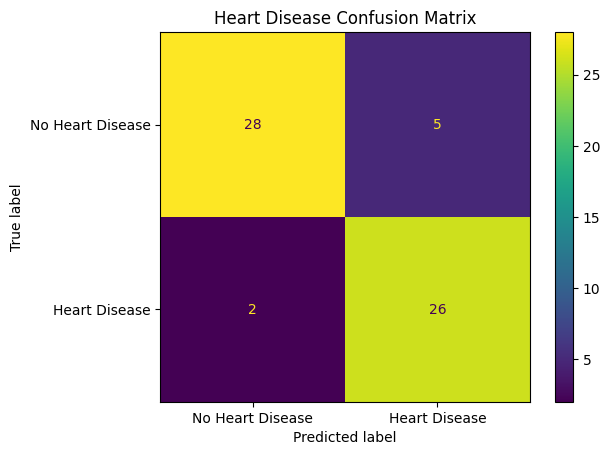

In [ ]:
## Heart Disease Confusion Matrix
cm_heart = confusion_matrix(
    y_heart_test,
    best_heart_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_heart,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

disp.plot()

plt.title("Heart Disease Confusion Matrix")
plt.show()

# Step 9: Final Model Comparison

The performance of the best model for each disease is compared using:

- Accuracy
- Precision
- Recall
- F1 Score

In [ ]:
final_results = pd.DataFrame({
    "Disease": [
        "Chronic Kidney Disease",
        "Heart Disease"
    ],

    "Best Model": [
        best_ckd_name,
        best_heart_name
    ],

    "Accuracy": [
        accuracy_score(
            y_ckd_test,
            best_ckd_predictions
        ),
        accuracy_score(
            y_heart_test,
            best_heart_predictions
        )
    ],

    "Precision": [
        precision_score(
            y_ckd_test,
            best_ckd_predictions,
            zero_division=0
        ),
        precision_score(
            y_heart_test,
            best_heart_predictions,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_ckd_test,
            best_ckd_predictions,
            zero_division=0
        ),
        recall_score(
            y_heart_test,
            best_heart_predictions,
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_ckd_test,
            best_ckd_predictions,
            zero_division=0
        ),
        f1_score(
            y_heart_test,
            best_heart_predictions,
            zero_division=0
        )
    ]
})

display(final_results)

,Disease,Best Model,Accuracy,Precision,Recall,F1 Score
0,Chronic Kidney Disease,Random Forest,1.000000,1.00000,1.000000,1.000000
1,Heart Disease,Logistic Regression,0.885246,0.83871,0.928571,0.881356


## Final Model Performance

The table above contains the actual evaluation metrics calculated from the
held-out test data.

These values should be used in the project report instead of manually
entering accuracy, precision, recall, or F1-score values.

## Feature Importance

Feature importance shows which input features contributed most to the Random Forest model's predictions.

In [ ]:
def show_random_forest_importance(
    pipeline,
    numeric_cols,
    categorical_cols,
    title
):
    model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]

    if not isinstance(model, RandomForestClassifier):
        print("The selected best model is not Random Forest.")
        print("Feature importance plot is skipped.")
        return

    feature_names = (
        list(numeric_cols)
        +
        list(
            preprocessor
            .named_transformers_["categorical"]
            .named_steps["encoder"]
            .get_feature_names_out(categorical_cols)
        )
    )

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(10)

    plt.figure(figsize=(9, 5))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1]
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.show()

    return importance_df

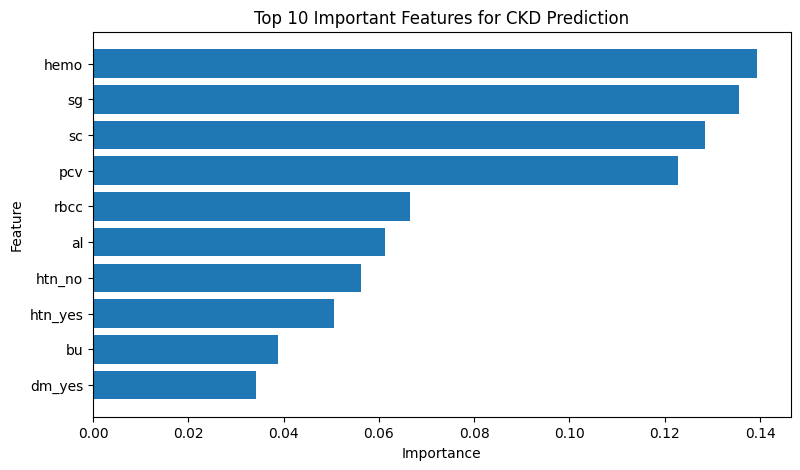

,Feature,Importance
10,hemo,0.139460
2,sg,0.135533
7,sc,0.128505
11,pcv,0.122887
13,rbcc,0.066427
3,al,0.061304
22,htn_no,0.056292
23,htn_yes,0.050592
6,bu,0.038784
26,dm_yes,0.034144


In [ ]:
ckd_importance = show_random_forest_importance(
    best_ckd_model,
    ckd_numeric_cols,
    ckd_categorical_cols,
    "Top 10 Important Features for CKD Prediction"
)

display(ckd_importance)

In [ ]:
import joblib

# Save the best CKD model
joblib.dump(best_ckd_model, "ckd_model.pkl")

# Save the best Heart Disease model
joblib.dump(best_heart_model, "heart_model.pkl")

print("Models saved successfully!")
print("1. ckd_model.pkl")
print("2. heart_model.pkl")

Models saved successfully!
1. ckd_model.pkl
2. heart_model.pkl


In [ ]:
# Load the saved models
loaded_ckd_model = joblib.load("ckd_model.pkl")
loaded_heart_model = joblib.load("heart_model.pkl")

print("CKD model loaded successfully.")
print("Heart Disease model loaded successfully.")

CKD model loaded successfully.
Heart Disease model loaded successfully.


In [ ]:
from google.colab import files

files.download("ckd_model.pkl")
files.download("heart_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>